# Exact Token Count Calculator
### US Transportation & Planning Job Descriptions

**Prepared by:** Sri Nikhil Jemili | **Advisor:** Professor Meiqing Li

---

**Purpose:** This notebook calculates the **exact** number of tokens our 74,309 US job descriptions will use when sent to a commercial LLM API (like GPT-4o-mini). It uses OpenAI's official tokenizer (`tiktoken`) so the counts are precise, not estimates.

**What are tokens?** Tokens are subword chunks that a model's tokenizer splits text into. Common words like "planning" = 1 token. Rare words like "NEPA" might become 2 tokens ("NE" + "PA"). The standard rule of thumb is 1 token ≈ 4 characters, but this notebook gives us the **real** number for our specific dataset.

## Step 1: Install Required Packages

In [1]:
!pip install tiktoken pandas pyarrow -q
print("All packages installed!")

All packages installed!


## Step 2: Load the Dataset

This dataset is already filtered to US-only postings from our EDA phase.

In [2]:
import pandas as pd
import tiktoken
import time
import numpy as np

# ============================================================
# UPDATE THESE IF NEEDED
# ============================================================
FILE_PATH = r"C:\Users\Nikhil\OneDrive\Documents\urban-ai-planning\data\processed\us_only_dataset.parquet"
JOB_DESC_COLUMN = "job_description"             # Column with job description text
COUNTRY_COLUMN = None                              # Already US-only dataset, no filter needed
# ============================================================

# Load
df = pd.read_parquet(FILE_PATH)
print(f"Total rows loaded: {len(df):,}")
print(f"Columns: {list(df.columns)}")

Total rows loaded: 74,309
Columns: ['base_hash', 'city', 'company_id', 'company_name', 'country', 'created', 'delete_date', 'job_hash', 'last_checked', 'last_updated', 'state', 'title', 'unmapped_location', 'url', 'zip', '_meta_loaded_at', 'onet_occupation_code', 'job_description', 'onet_occupation_code_desc', 'remote_detail', 'fulltime_parttime', 'category', 'year']


In [3]:
# Dataset is already US-only, no filtering needed
print(f"US-only dataset loaded: {len(df):,} postings")

# Drop empty descriptions
before = len(df)
df = df.dropna(subset=[JOB_DESC_COLUMN])
df = df[df[JOB_DESC_COLUMN].str.strip().str.len() > 0]
print(f"Postings with valid descriptions: {len(df):,} (dropped {before - len(df)} empty)")

US-only dataset loaded: 74,309 postings
Postings with valid descriptions: 74,309 (dropped 0 empty)


## Step 3: Quick Look at Our Job Descriptions

In [4]:
# Character length stats
df["char_count"] = df[JOB_DESC_COLUMN].str.len()

print("Character count per job description:")
print(f"  Mean:   {df['char_count'].mean():,.0f}")
print(f"  Median: {df['char_count'].median():,.0f}")
print(f"  Min:    {df['char_count'].min():,}")
print(f"  Max:    {df['char_count'].max():,}")
print(f"\nOur earlier estimate assumed ~5,500 chars average. Actual average: {df['char_count'].mean():,.0f}")

Character count per job description:
  Mean:   5,540
  Median: 4,532
  Min:    1
  Max:    43,122

Our earlier estimate assumed ~5,500 chars average. Actual average: 5,540


## Step 4: Define Our Prompt Template
This is the instruction we send with each job description. Its token count is a fixed overhead added to every API call.

In [5]:
PROMPT_TEMPLATE = """Extract all skills mentioned in the following job description.
Categorize each skill as either "technical" or "soft".
Return the results as a JSON list with fields: skill_name, skill_type.
Only include skills explicitly mentioned or clearly implied in the text.

Job Description:
{job_description}"""

print("Prompt template:")
print("-" * 50)
print(PROMPT_TEMPLATE.replace("{job_description}", "[JOB DESCRIPTION GOES HERE]"))
print("-" * 50)

Prompt template:
--------------------------------------------------
Extract all skills mentioned in the following job description.
Categorize each skill as either "technical" or "soft".
Return the results as a JSON list with fields: skill_name, skill_type.
Only include skills explicitly mentioned or clearly implied in the text.

Job Description:
[JOB DESCRIPTION GOES HERE]
--------------------------------------------------


## Step 5: Tokenize Everything
This is the main step where we run every job description through GPT-4o-mini's exact tokenizer.

In [13]:
# Load GPT-4o-mini tokenizer
encoder = tiktoken.get_encoding("o200k_base")
print("Tokenizer loaded: o200k_base (used by GPT-4o and GPT-4o-mini)")

# Tokenize the prompt template (fixed overhead)
prompt_without_desc = PROMPT_TEMPLATE.replace("{job_description}", "")
prompt_tokens = len(encoder.encode(prompt_without_desc))
print(f"Prompt overhead per posting: {prompt_tokens} tokens")

Tokenizer loaded: o200k_base (used by GPT-4o and GPT-4o-mini)
Prompt overhead per posting: 54 tokens


In [14]:
# Tokenize all job descriptions
print(f"Tokenizing {len(df):,} job descriptions...")
start = time.time()

token_counts = []
for i, text in enumerate(df[JOB_DESC_COLUMN]):
    token_counts.append(len(encoder.encode(str(text))))
    if (i + 1) % 10000 == 0:
        elapsed = time.time() - start
        print(f"  {i+1:,} / {len(df):,} ({(i+1)/len(df)*100:.0f}%) — {elapsed:.1f}s")

df["token_count"] = token_counts
print(f"\nDone {len(df):,} descriptions tokenized in {time.time()-start:.1f} seconds")

Tokenizing 74,309 job descriptions...
  10,000 / 74,309 (13%) — 5.5s
  20,000 / 74,309 (27%) — 10.1s
  30,000 / 74,309 (40%) — 17.3s
  40,000 / 74,309 (54%) — 23.5s
  50,000 / 74,309 (67%) — 29.0s
  60,000 / 74,309 (81%) — 35.0s
  70,000 / 74,309 (94%) — 40.7s

Done 74,309 descriptions tokenized in 43.3 seconds


## Step 6: See a Concrete Example
Let's look at how one actual job description from our dataset gets tokenized

In [16]:
# Pick a posting close to the median length
median_tokens = int(df["token_count"].median())
example_row = df.iloc[(df["token_count"] - median_tokens).abs().argsort().iloc[0]]
example_text = str(example_row[JOB_DESC_COLUMN])

# Show first 300 characters
print("Example job description (first 300 chars):")
print("-" * 50)
print(example_text[:300] + "...")
print("-" * 50)
print(f"Full length: {len(example_text):,} characters → {example_row['token_count']:,} tokens")
print(f"Ratio: {len(example_text) / example_row['token_count']:.2f} characters per token")

# Show how a small snippet tokenizes
snippet = example_text[:150]
snippet_tokens = encoder.encode(snippet)
decoded = [encoder.decode([t]) for t in snippet_tokens]
print(f"\nFirst 150 characters tokenized into {len(snippet_tokens)} tokens:")
print(decoded)

Example job description (first 300 chars):
--------------------------------------------------
Worldwide Mobility and Relocation Solutions in 165 Countries

Join the Graebel team to build or expand your new career! We provide talent mobility and relocation solutions to Global 1000 firms and their employees. We pride ourselves on delivering exceptional customer service, and believe that happy ...
--------------------------------------------------
Full length: 4,628 characters → 823 tokens
Ratio: 5.62 characters per token

First 150 characters tokenized into 29 tokens:
['Worldwide', ' Mobility', ' and', ' Rel', 'ocation', ' Solutions', ' in', ' ', '165', ' Countries', '\n\n', 'Join', ' the', ' Gra', 'ebel', ' team', ' to', ' build', ' or', ' expand', ' your', ' new', ' career', '!', ' We', ' provide', ' talent', ' mobility', ' and']


## Step 7: Token Count Statistics
Here are the exact numbers across our full dataset.

In [17]:
n = len(df)
total_desc_tokens = df["token_count"].sum()
total_prompt_tokens = prompt_tokens * n
total_input_tokens = total_desc_tokens + total_prompt_tokens

# Output tokens are estimated (we'd need to run the model to know exactly)
est_output_per_posting = 300
total_output_tokens = est_output_per_posting * n

avg_chars = df["char_count"].mean()
avg_tokens = df["token_count"].mean()
actual_ratio = avg_chars / avg_tokens

print("=" * 60)
print("  EXACT TOKEN COUNT RESULTS")
print("=" * 60)
print()
print("PER POSTING (Job Description Only):")
print(f"  Mean tokens:     {avg_tokens:,.0f}")
print(f"  Median tokens:   {df['token_count'].median():,.0f}")
print(f"  Min tokens:      {df['token_count'].min():,}")
print(f"  Max tokens:      {df['token_count'].max():,}")
print(f"  Std deviation:   {df['token_count'].std():,.0f}")
print()
print(f"ACTUAL RATIO: {actual_ratio:.2f} chars per token")
print(f"  (vs. the commonly used estimate of 4.0)")
print()
print("-" * 60)
print("FULL DATASET TOTALS:")
print(f"  Total postings:              {n:>15,}")
print(f"  Description tokens:          {total_desc_tokens:>15,}")
print(f"  + Prompt overhead:           {total_prompt_tokens:>15,}")
print(f"  ─────────────────────────────────────────────")
print(f"  EXACT TOTAL INPUT TOKENS:    {total_input_tokens:>15,}")
print(f"  Est. total output tokens:    {total_output_tokens:>15,}")
print(f"    (output uses {est_output_per_posting} tokens/posting estimate)")
print()
print(f"COMPARISON TO OUR EARLIER ESTIMATE:")
print(f"  Earlier estimate (input):    {'119,000,000':>15}")
print(f"  Exact count (input):         {total_input_tokens:>15,}")
diff_pct = (total_input_tokens - 119_000_000) / 119_000_000 * 100
print(f"  Difference:                  {diff_pct:>14.1f}%")
print("=" * 60)

  EXACT TOKEN COUNT RESULTS

PER POSTING (Job Description Only):
  Mean tokens:     1,022
  Median tokens:   823
  Min tokens:      1
  Max tokens:      8,296
  Std deviation:   848

ACTUAL RATIO: 5.42 chars per token
  (vs. the commonly used estimate of 4.0)

------------------------------------------------------------
FULL DATASET TOTALS:
  Total postings:                       74,309
  Description tokens:               75,913,429
  + Prompt overhead:                 4,012,686
  ─────────────────────────────────────────────
  EXACT TOTAL INPUT TOKENS:         79,926,115
  Est. total output tokens:         22,292,700
    (output uses 300 tokens/posting estimate)

COMPARISON TO OUR EARLIER ESTIMATE:
  Earlier estimate (input):        119,000,000
  Exact count (input):              79,926,115
  Difference:                           -32.8%


## Step 8: Token Distribution Visualization
A histogram showing how token counts are distributed across our postings.

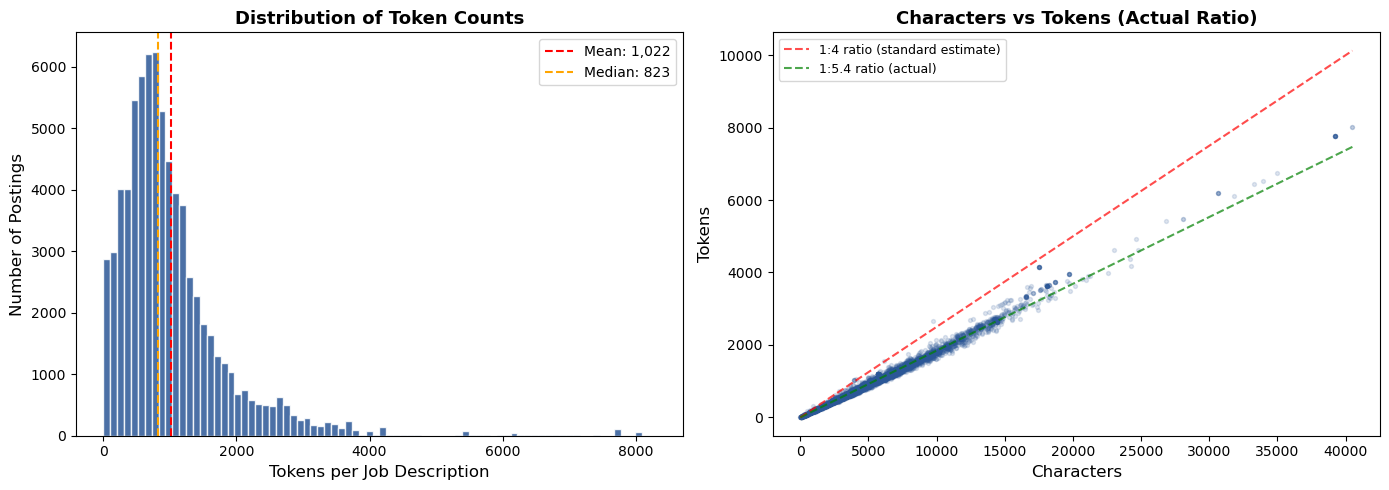

Chart saved to: token_distribution.png


In [18]:
import matplotlib.pyplot as plt

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Histogram
axes[0].hist(df["token_count"], bins=80, color="#2B5797", edgecolor="white", alpha=0.85)
axes[0].axvline(avg_tokens, color="red", linestyle="--", linewidth=1.5, label=f"Mean: {avg_tokens:,.0f}")
axes[0].axvline(df["token_count"].median(), color="orange", linestyle="--", linewidth=1.5, label=f"Median: {df['token_count'].median():,.0f}")
axes[0].set_xlabel("Tokens per Job Description", fontsize=12)
axes[0].set_ylabel("Number of Postings", fontsize=12)
axes[0].set_title("Distribution of Token Counts", fontsize=13, fontweight="bold")
axes[0].legend(fontsize=10)

# Characters vs Tokens scatter (sample for speed)
sample = df.sample(min(5000, len(df)), random_state=42)
axes[1].scatter(sample["char_count"], sample["token_count"], alpha=0.15, s=8, color="#2B5797")
# Add reference lines
max_char = sample["char_count"].max()
axes[1].plot([0, max_char], [0, max_char/4], "--", color="red", alpha=0.7, label="1:4 ratio (standard estimate)")
axes[1].plot([0, max_char], [0, max_char/actual_ratio], "--", color="green", alpha=0.7, label=f"1:{actual_ratio:.1f} ratio (actual)")
axes[1].set_xlabel("Characters", fontsize=12)
axes[1].set_ylabel("Tokens", fontsize=12)
axes[1].set_title("Characters vs Tokens (Actual Ratio)", fontsize=13, fontweight="bold")
axes[1].legend(fontsize=9)

plt.tight_layout()
plt.savefig("token_distribution.png", dpi=150, bbox_inches="tight")
plt.show()
print("Chart saved to: token_distribution.png")

## Step 9: Exact Cost Calculation

In [22]:
# API pricing ($ per 1 million tokens) — early 2025 rates
pricing = {
    "GPT-4o-mini":      {"input": 0.15,  "output": 0.60},
    "Gemini 1.5 Flash": {"input": 0.08,  "output": 0.30},
    "Gemini 1.5 Pro":   {"input": 1.25,  "output": 5.00},
    "GPT-4o":           {"input": 2.50,  "output": 10.00},
    "Claude Sonnet":    {"input": 3.00,  "output": 15.00},
}

print("=" * 70)
print("  EXACT COST ESTIMATES BY MODEL")
print(f"  Based on {total_input_tokens:,} input tokens + {total_output_tokens:,} est. output tokens")
print("=" * 70)
print(f"  {'Model':<20} {'Input $/1M':>10} {'Output $/1M':>11} {'Input $':>10} {'Output $':>10} {'TOTAL':>10}")
print("  " + "-" * 66)

cost_data = []
for model, p in pricing.items():
    ic = (total_input_tokens / 1_000_000) * p["input"]
    oc = (total_output_tokens / 1_000_000) * p["output"]
    total = ic + oc
    print(f"  {model:<20} ${p['input']:>8.2f} ${p['output']:>9.2f} ${ic:>8.2f} ${oc:>8.2f} ${total:>8.2f}")
    cost_data.append({"Model": model, "Input_Cost": round(ic,2), "Output_Cost": round(oc,2), "Total": round(total,2)})

print("  " + "-" * 66)
print()

costs_df = pd.DataFrame(cost_data)
print("Recommendation: GPT-4o-mini as validation benchmark alongside free Llama 3 on Newton cluster.")

  EXACT COST ESTIMATES BY MODEL
  Based on 79,926,115 input tokens + 22,292,700 est. output tokens
  Model                Input $/1M Output $/1M    Input $   Output $      TOTAL
  ------------------------------------------------------------------
  GPT-4o-mini          $    0.15 $     0.60 $   11.99 $   13.38 $   25.36
  Gemini 1.5 Flash     $    0.08 $     0.30 $    6.39 $    6.69 $   13.08
  Gemini 1.5 Pro       $    1.25 $     5.00 $   99.91 $  111.46 $  211.37
  GPT-4o               $    2.50 $    10.00 $  199.82 $  222.93 $  422.74
  Claude Sonnet        $    3.00 $    15.00 $  239.78 $  334.39 $  574.17
  ------------------------------------------------------------------

Recommendation: GPT-4o-mini as validation benchmark alongside free Llama 3 on Newton cluster.


## Step 10: Save Results

In [24]:
# Summary stats
summary = pd.DataFrame([{
    "total_postings": n,
    "avg_chars_per_posting": round(avg_chars, 0),
    "avg_tokens_per_posting": round(avg_tokens, 0),
    "median_tokens_per_posting": int(df["token_count"].median()),
    "min_tokens": int(df["token_count"].min()),
    "max_tokens": int(df["token_count"].max()),
    "actual_chars_per_token_ratio": round(actual_ratio, 2),
    "prompt_tokens_per_posting": prompt_tokens,
    "exact_total_input_tokens": total_input_tokens,
    "est_total_output_tokens": total_output_tokens,
}])


---
## Summary

This notebook computed **exact** token counts using OpenAI's official `tiktoken` tokenizer (the `o200k_base` encoding used by GPT-4o-mini and GPT-4o). Key points:

- **Tokens** are subword chunks, not characters or words. Each model family has its own tokenizer.
- The standard estimate of **1 token ≈ 4 characters** is a rough approximation. The actual ratio for our dataset is shown above.
- **Input tokens** = job description + prompt instruction. This is now an **exact count**, not an estimate.
- **Output tokens** = the model's response (still estimated at ~300/posting until we run a sample).
- All costs above are calculated from these exact/estimated totals using each provider's published per-million-token pricing.